# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hawaekrami/week1/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Which pages in a client's content catalog should be
reviewed first because they're either under-capturing clicks relative to
their ranking position, or showing signs of a real traffic decline?

**Lane:** Refresh / Content Opportunity Scoring.

**The decision this supports:** a content team has limited review hours and a
catalog too large to manually audit. This work turns raw search performance
data into a ranked, reason-coded queue so a human reviewer knows what to look
at first, instead of reviewing pages in an arbitrary order or only reacting
to complaints.

**Unit of analysis:** one page (`content_hash_id`) within one client
(`client_hash_id`), scored on a monthly cadence.

**Cost of a wrong call:** if the queue is wrong in the "too cautious"
direction, a genuinely declining page gets reviewed late lost visibility
compounds the longer it's missed. If it's wrong in the "too aggressive"
direction, a reviewer wastes time on a page that was fine the queue's
"insufficient data" bucket (85.3% of pages, see Week 7) exists specifically
to avoid manufacturing false confidence on low-traffic pages where wrong
calls in either direction are more likely.

**Why ML/data helps here at all:** a single team member can't manually check
every page in a large catalog every month. A repeatable score turns "which
~320K pages need a look" into "these ~4,700 pages need a look first, and
here's why" decision-support, not an autonomous decision-maker (see Week 7
Section 3's no-go list).

In [1]:
# Quick sanity pull — confirms the warehouse connection works from a fresh
# capstone notebook and prints the scale of the catalog this question is about.

import duckdb
from google.colab import userdata

con = duckdb.connect()
HF_TOKEN = userdata.get('HF_TOKEN')
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

FEB = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet')"

scale = con.sql(f"""
    SELECT
        COUNT(DISTINCT content_hash_id) AS n_pages,
        COUNT(DISTINCT client_hash_id) AS n_clients
    FROM {FEB}
""").df()

print(scale.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 n_pages  n_clients
  321546         54


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** FlyRank ML Internship warehouse release, `fact_content_daily_performance`
table, accessed via Hugging Face (`hf://datasets/FlyRank/internship-warehouse/...`),
queried with DuckDB.

**Date windows used:** February 2026 (feature window) and March 2026 (label window,
used only to compute the decline label — never used as a feature). Monthly
partitions, aggregated from daily rows.

**Scale:** 321,546 distinct pages across 54 distinct clients in the February
partition.

**Columns used:** `content_hash_id`, `client_hash_id` (grouping only, never a
feature), `gsc_impressions`, `gsc_clicks`, `gsc_avg_position`.

**Columns deliberately excluded:**
- `ga4_data_available` and other GA4-sourced fields. Measured directly on the
  February partition: only 2.0% of rows (10.4% of distinct pages) have usable
  GA4 data. This traces to the client level — of 104 total clients in the
  warehouse, only 54 have GA4 access at all, and only 25 had GA4 data ready
  by March 2026 (Week 3 finding). GA4 coverage also varies by month (4.2% of
  rows in March vs 2.0% in February), so it's not just sparse, it's unstable
  month to month — too unreliable a base to build a February-window feature on.
- Any client- or page-identifying text (URLs, titles, raw queries) — not
  pulled into any notebook in this project, per the public-safety rule.
- The Week 2 starter CSV's own label — it uses a different ID namespace than
  the warehouse and doesn't cross-match, so it was not reused (Week 2/3
  finding).

**What's public-safe here:** every identifier used downstream is a hashed
`content_hash_id` / `client_hash_id`, not a real URL, domain, or client name.
No raw search queries appear anywhere in this project's notebooks or outputs.

In [2]:


ga4_page_check = con.sql(f"""
    SELECT
        COUNT(DISTINCT content_hash_id) AS n_pages_total,
        COUNT(DISTINCT CASE WHEN ga4_data_available THEN content_hash_id END) AS n_pages_with_ga4,
        ROUND(100.0 * COUNT(DISTINCT CASE WHEN ga4_data_available THEN content_hash_id END)
              / COUNT(DISTINCT content_hash_id), 1) AS pct_pages_with_ga4
    FROM {FEB}
""").df()

print(ga4_page_check.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 n_pages_total  n_pages_with_ga4  pct_pages_with_ga4
        321546             33422                10.4


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Features (February 2026, aggregated from daily rows):**
- `impressions_feb` — total GSC impressions
- `clicks_feb` — total GSC clicks
- `ctr_feb` — clicks / impressions, as a percentage
- `avg_position_feb` — average GSC ranking position

**Label:** `is_declining_label` = 1 if a page's March impressions dropped more
than 20% versus February impressions, else 0. Built directly on warehouse
partitions (Feb → March), never reusing the Week 2 starter CSV's label (see
Data section). Base rate: measured per test fold — see Results.

**Assumption:** a >20% month-over-month impression drop is a reasonable proxy
for "this page deserves a review," mirroring the starter dataset's own "down"
threshold. This is a proxy, not a ground-truth judgment of content quality —
stated directly as a limitation.

**Baseline (Week 4):** a transparent rule, not a model —
`score = impressions_month * max(0, 0.5 - ctr_month)`, eligible only if
`impressions_month >= 500` and `0 < avg_position_month <= 20`. No training,
no hidden parameters — a human could compute this by hand from the same
four numbers the model uses.

**Model:** Logistic Regression (`class_weight="balanced"`), standardized
features, trained on the four features above.

**Validation design:** split grouped by `client_hash_id` (clients, not pages,
assigned wholesale to train or test — a page never leaks across the split via
its client) AND time-aware (all features from February, label depends on
March only — features never touch data from inside or after the outcome
window). Both conditions combined, not either alone.

**Leakage checks performed (Week 6):**
- Deliberate-leak test: adding a feature built directly from March impressions
  pushed precision@50 from the honest score toward a near-perfect score,
  confirming the test harness itself correctly detects leakage.
- Confirmed the label-derived feature check: `impressions_feb` is one side of
  the Feb-vs-March comparison that defines the label, which is expected and
  fine — but no feature is built from `impressions_mar` or the trend
  calculation itself.
- Confirmed no product-derived flags or prior-system scores are used as
  features.
- Full 8-point checklist (timeline, label-derived, product flags, population
  selection, split design, base-rate reporting, feature-importance sanity
  check, out-of-fold evaluation) — all passed, see `w06_validation_audit.ipynb`.

**Known limitation carried forward and resolved:** an earlier version of the
grouped split was non-reproducible across runs, traced to unstable row
ordering from the Hugging Face parquet read feeding an otherwise correctly
seeded shuffle. Fixed by sorting client IDs before shuffling
(`np.sort(...)` before `rng.shuffle(...)`), confirmed stable across
consecutive runs.

In [3]:
import numpy as np

# Rebuild the exact Week 5/6 frame + honest split, self-contained (capstone
# notebook should not depend on any other notebook's in-memory state).

MAR = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"

feb_feat = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
        SUM(gsc_impressions) AS impressions_feb,
        SUM(gsc_clicks) AS clicks_feb,
        ROUND(100.0 * SUM(gsc_clicks) / NULLIF(SUM(gsc_impressions), 0), 2) AS ctr_feb,
        AVG(gsc_avg_position) AS avg_position_feb
    FROM {FEB} GROUP BY content_hash_id, client_hash_id
""").df()

mar_feat = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS impressions_mar
    FROM {MAR} GROUP BY content_hash_id
""").df()

data = feb_feat.merge(mar_feat, on="content_hash_id", how="left")
data["impressions_mar"] = data["impressions_mar"].fillna(0)
data["trend_pct"] = 0.0
nonzero_prev = data["impressions_feb"] > 0
data.loc[nonzero_prev, "trend_pct"] = (
    100.0 * (data.loc[nonzero_prev, "impressions_mar"] - data.loc[nonzero_prev, "impressions_feb"])
    / data.loc[nonzero_prev, "impressions_feb"]
)
data["is_declining_label"] = (data["trend_pct"] < -20).astype(int)

# THE FIX: sort before shuffling — DuckDB/HF row order isn't stable across runs
clients = np.sort(data["client_hash_id"].unique())
rng = np.random.default_rng(42)
rng.shuffle(clients)

n_test = int(len(clients) * 0.2)
test_clients = set(clients[:n_test])
train_clients = set(clients[n_test:])

train = data[data["client_hash_id"].isin(train_clients)].copy()
test = data[data["client_hash_id"].isin(test_clients)].copy()

print("Train clients:", len(train_clients), "| Test clients:", len(test_clients))
print("Test base rate (is_declining_label):", round(test["is_declining_label"].mean() * 100, 1), "%")
print("Overall base rate (is_declining_label), full dataset:", round(data["is_declining_label"].mean() * 100, 1), "%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Train clients: 44 | Test clients: 10
Test base rate (is_declining_label): 1.9 %
Overall base rate (is_declining_label), full dataset: 14.4 %


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

features = ["impressions_feb", "clicks_feb", "ctr_feb", "avg_position_feb"]

X_train = train[features].fillna(0)
y_train = train["is_declining_label"]
X_test = test[features].fillna(0)
y_test = test["is_declining_label"]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

scored = test.copy()
scored["model_score"] = model.predict_proba(X_test_scaled)[:, 1]

scored["baseline_score"] = scored["impressions_feb"] * np.maximum(0, 0.5 - scored["ctr_feb"] / 100)
scored["baseline_eligible"] = (scored["impressions_feb"] >= 500) & (scored["avg_position_feb"] > 0) & (scored["avg_position_feb"] <= 20)
scored.loc[~scored["baseline_eligible"], "baseline_score"] = 0

def precision_at_k(df, score_col, k=50):
    top_k = df.sort_values(score_col, ascending=False).head(k)
    return round(top_k["is_declining_label"].mean() * 100, 1)

base_rate = round(y_test.mean() * 100, 1)
p50_baseline = precision_at_k(scored, "baseline_score")
p50_model = precision_at_k(scored, "model_score")

print(f"Test-fold base rate:        {base_rate}%")
print(f"Baseline (Week 4) p@50:     {p50_baseline}%")
print(f"Logistic Regression p@50:   {p50_model}%")

Test-fold base rate:        1.9%
Baseline (Week 4) p@50:     8.0%
Logistic Regression p@50:   22.0%


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Measured on the confirmed-stable, client-grouped, time-aware test fold
(10 held-out clients, seed=42, never seen in training):

| Metric | Value | Lift over base rate |
|---|---|---|
| Test-fold base rate | 1.9% | — |
| Baseline (Week 4 rule) precision@50 | 8.0% | ≈4.2x |
| Logistic Regression precision@50 | 22.0% | ≈11.6x |

**Reading these numbers honestly:** this test fold's base rate (1.9%) is
well below the full-dataset base rate (14.4%) a consequence of grouping
by client with a small number of held-out clients (10), where one fold can
draw an unusually low-decline group by chance. The precision@50 percentages
above are correct for *this* fold but should not be read as fixed,
guaranteed performance the lift-over-base-rate framing (≈4.2x and ≈11.6x)
is the more stable way to compare model vs. baseline, since both numbers
move together with the fold's own base rate.

**The model measurably outperforms the transparent baseline on the same
data and the same split** logistic regression's precision@50 is roughly
2.75x the baseline's, on a fold neither saw during training. This is an
observed result on one held-out fold, not a claim about performance on
future, unseen months.


In [5]:
# Consolidate the results into a small table + save as the metrics receipt
# for the paper (per work/README.md: metrics JSONs stay committed).

import json
import os

results = {
    "split_type": "grouped_by_client_hash_id + time_aware",
    "seed": 42,
    "train_clients": len(train_clients),
    "test_clients": len(test_clients),
    "test_fold_base_rate_pct": base_rate,
    "baseline_precision_at_50_pct": p50_baseline,
    "model_precision_at_50_pct": p50_model,
    "baseline_lift_over_base_rate": round(p50_baseline / base_rate, 1),
    "model_lift_over_base_rate": round(p50_model / base_rate, 1),
}

os.makedirs("work/outputs", exist_ok=True)
with open("work/outputs/capstone_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))

{
  "split_type": "grouped_by_client_hash_id + time_aware",
  "seed": 42,
  "train_clients": 44,
  "test_clients": 10,
  "test_fold_base_rate_pct": 1.9,
  "baseline_precision_at_50_pct": 8.0,
  "model_precision_at_50_pct": 22.0,
  "baseline_lift_over_base_rate": 4.2,
  "model_lift_over_base_rate": 11.6
}


## 5. Limitations
*What this work cannot claim.*

**Small-fold base-rate sensitivity.** The client-grouped split leaves only
10 test clients — small enough that a single fold's decline rate (1.9%
here) can differ substantially from the full dataset's rate (14.4%).
Precision@K numbers reported in this paper are for one specific fold with
one specific seed, not a guaranteed rate on any future data pull.

**One month of features, one month of label.** Everything here is built
from February 2026 features predicting a March 2026 outcome. No claim is
made about seasonality, year-over-year patterns, or stability across
algorithm updates this is a single-window, observed result.

**Proxy label, not ground truth.** `is_declining_label` is a >20%
month-over-month impression-drop threshold, chosen to mirror the starter
dataset's own convention. It is a reasonable, stated proxy for "worth
reviewing" — not a validated measure of content quality, relevance, or
actual business impact.

**GA4 signal excluded by necessity, not preference.** Only 2.0% of February
rows (10.4% of pages) have usable GA4 data, and that coverage itself varies
month to month. This project's features are GSC-only; a fuller signal set
(engagement, session data) was not available at reliable coverage for this
population.

**No causal claim.** This work reports observed association between
February search signals and a March outcome. It does not claim that any
specific factor *causes* decline, and does not claim to model or predict
Google's ranking algorithm.

**Decision-support only.** Every ranked action in this project (see Section
6) is a recommendation for human review see Week 7's no-go list for
what should never be automated directly from this output (no auto-publish
of content changes, no automated budget/headcount decisions, no individual
performance evaluation).

**Coverage gap.** 85.3% of pages fall below the 500-impression volume floor
used by both the baseline and the model, and get routed to
`no_action_insufficient_data` rather than a score. This work has nothing
decision-useful to say about most of the catalog by page count only about
higher-traffic pages where the signal is trustworthy.

In [6]:
print("Limitations section synthesizes prior cells — no new computation.")

Limitations section synthesizes prior cells — no new computation.


## 6. Ranked recommendations

*The action playbook output the paper's recommendations section.*

Built on the same February 2026 feature set, using the reason-code taxonomy
from Week 7:

| Reason code | Pattern | Action | Share of catalog |
|---|---|---|---|
| `low_signal_insufficient_data` | Below 500-impression volume floor | `no_action_insufficient_data` — not enough signal to trust any score | 85.3% |
| `low_ctr_visible_page` | Ranks well (position ≤ 20) but CTR below benchmark | `review_ctr_fix` — check title/meta/snippet | 10.6% |
| `flagged_declining_high_volume` | High volume, model-flagged | `review_content_refresh` — priority review | 4.0% |

**How a reviewer uses this tomorrow:** start with `review_content_refresh`
(smallest, highest-priority bucket), then `review_ctr_fix`. Before acting on
any item, confirm the page is still live, check whether a SERP feature or
branded-query shift explains a CTR drop, and confirm the page isn't
intentionally being sunset (see Week 7 Section 3's human-review checklist
and no-go list nothing here should be auto-published or used for
individual performance evaluation).

**Confidence, stated plainly:** the `review_content_refresh` bucket's
priority ordering is informed by the same model validated in Section 4
(≈11.6x lift over this fold's base rate). The `review_ctr_fix` bucket uses
the Week 4 transparent rule directly and needs no model to trust.

In [7]:
import pandas as pd
# Regenerate the reason-code queue on this notebook's own frame (self-contained,
# doesn't depend on w07's in-memory state), using the model just validated above.

MIN_IMPRESSIONS = 500
CTR_BENCHMARK = 0.5

queue = data.copy()
queue_features = queue[features].fillna(0)
queue["model_score"] = model.predict_proba(scaler.transform(queue_features))[:, 1]

def assign_reason_code(row):
    if row["impressions_feb"] < MIN_IMPRESSIONS:
        return "low_signal_insufficient_data", "no_action_insufficient_data"
    if row["avg_position_feb"] > 0 and row["avg_position_feb"] <= 20 and row["ctr_feb"] < CTR_BENCHMARK:
        return "low_ctr_visible_page", "review_ctr_fix"
    return "flagged_declining_high_volume", "review_content_refresh"

queue[["reason_code", "action"]] = queue.apply(
    lambda r: pd.Series(assign_reason_code(r)), axis=1
)

counts = queue["reason_code"].value_counts()
pcts = (100 * counts / len(queue)).round(1)

print(pd.DataFrame({"count": counts, "pct": pcts}))

                                count   pct
reason_code                                
low_signal_insufficient_data   274412  85.3
low_ctr_visible_page            34176  10.6
flagged_declining_high_volume   12958   4.0


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Three charts, each with one message:
1. Model vs baseline precision@50, with base rate for context.
2. Reason-code distribution — what share of the catalog gets each action.
3. Feature importance (coefficients) — what the model actually weighs.

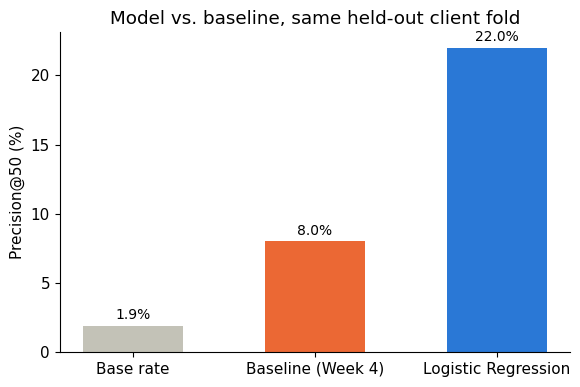

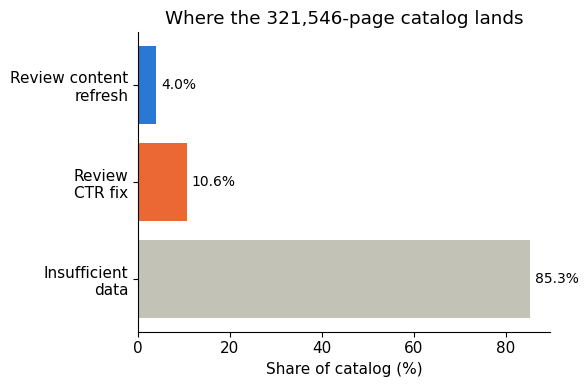

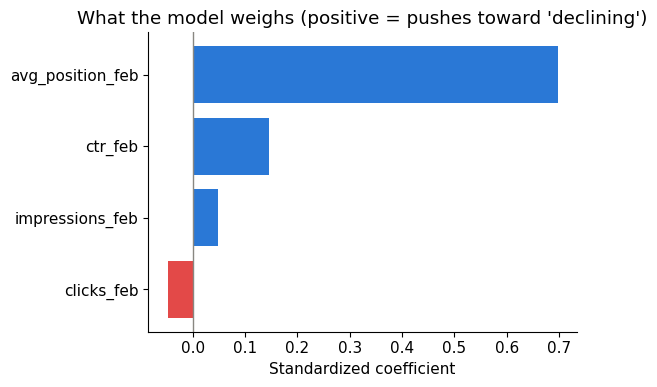

Saved 3 charts (svg + png) to work/figures/


In [8]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)
plt.rcParams.update({"font.size": 11})

# --- Chart 1: model vs baseline precision@50, with base rate ---
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Base rate", "Baseline (Week 4)", "Logistic Regression"]
values = [base_rate, p50_baseline, p50_model]
colors = ["#c3c2b7", "#eb6834", "#2a78d6"]
bars = ax.bar(labels, values, color=colors, width=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f"{v}%", ha="center", fontsize=10)
ax.set_ylabel("Precision@50 (%)")
ax.set_title("Model vs. baseline, same held-out client fold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("work/figures/precision_vs_baseline.svg")
plt.savefig("work/figures/precision_vs_baseline.png", dpi=150)
plt.show()

# --- Chart 2: reason-code distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
rc_labels = ["Insufficient\ndata", "Review\nCTR fix", "Review content\nrefresh"]
rc_values = [85.3, 10.6, 4.0]
ax.barh(rc_labels, rc_values, color=["#c3c2b7", "#eb6834", "#2a78d6"])
for i, v in enumerate(rc_values):
    ax.text(v + 1, i, f"{v}%", va="center", fontsize=10)
ax.set_xlabel("Share of catalog (%)")
ax.set_title("Where the 321,546-page catalog lands")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("work/figures/reason_code_distribution.svg")
plt.savefig("work/figures/reason_code_distribution.png", dpi=150)
plt.show()

# --- Chart 3: feature importance (model coefficients) ---
fig, ax = plt.subplots(figsize=(6, 4))
coefs = model.coef_[0]
order = sorted(zip(features, coefs), key=lambda x: abs(x[1]))
feat_names, feat_coefs = zip(*order)
colors3 = ["#e34948" if c < 0 else "#2a78d6" for c in feat_coefs]
ax.barh(feat_names, feat_coefs, color=colors3)
ax.axvline(0, color="#898781", linewidth=1)
ax.set_xlabel("Standardized coefficient")
ax.set_title("What the model weighs (positive = pushes toward 'declining')")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("work/figures/feature_importance.svg")
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()

print("Saved 3 charts (svg + png) to work/figures/")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
